In [1]:
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('/home/users/akshay/PCPpred/Caco2/features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv')

/tmp/ipykernel_3610599/2894403661.py:1: DtypeWarning: Columns (1275,1277,1280,1285,1298,1354,1356,1359,1364,1377,1579,1580,1581,1583,1584,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/home/users/akshay/PCPpred/Caco2/features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv')


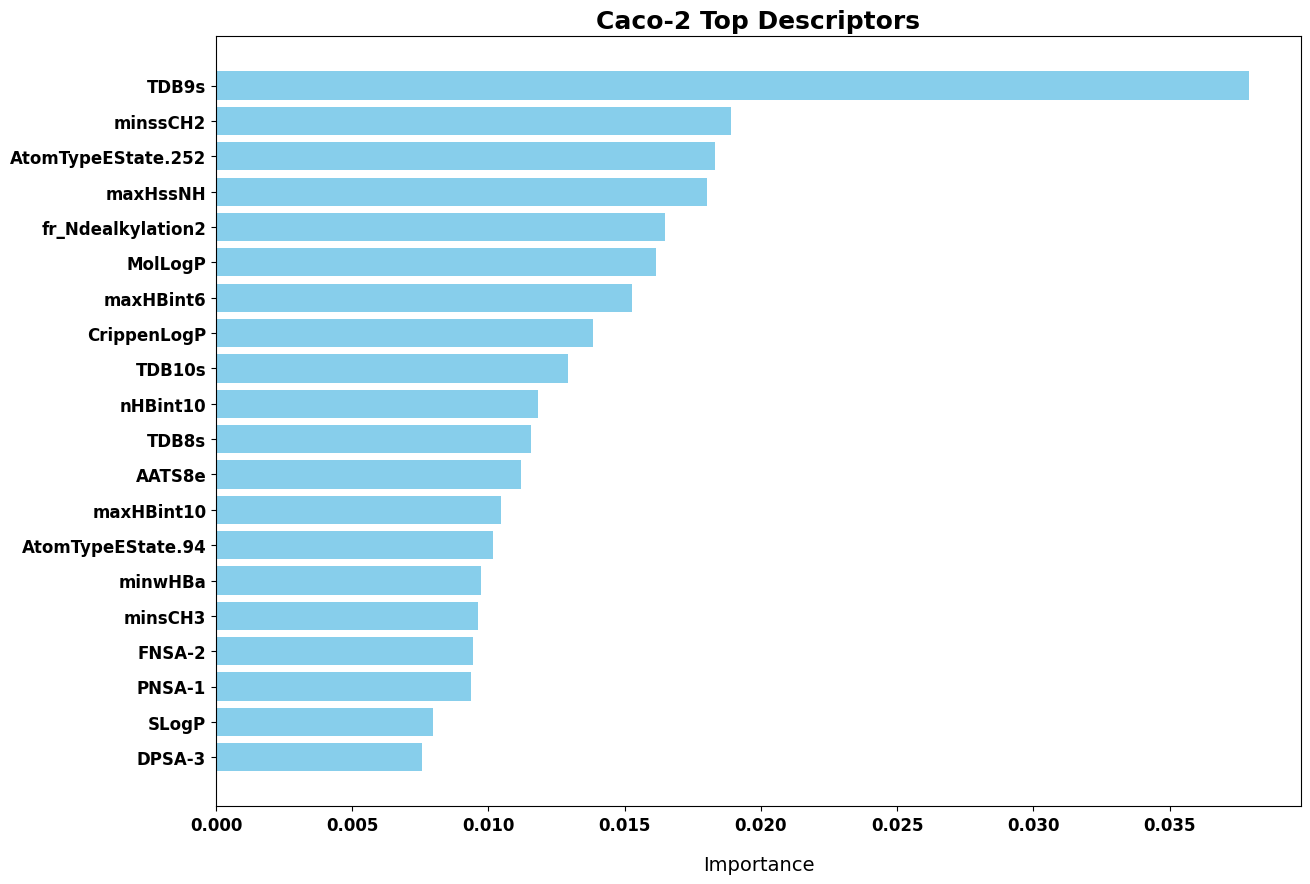

In [3]:
X_train = df1.drop(columns=['ID', 'SMILES', 'Permeability'])
X_train = X_train.select_dtypes(include=['number'])
y_train = df1['Permeability']

ET_model = ExtraTreesRegressor(n_jobs=-1, n_estimators=100, random_state=101)
ET_model.fit(X_train, y_train)

ET_importance_all = ET_model.feature_importances_
ET_feature_importance_df_all = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': ET_importance_all
})
ET_top_features_all = ET_feature_importance_df_all.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(14, 10))
bars = plt.barh(ET_top_features_all['Feature'], ET_top_features_all['Importance'], color='skyblue')

plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')

plt.xlabel('Importance', fontsize=14, labelpad=15)
plt.title('Caco-2 Top Descriptors', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()

save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/imp_features_plot_caco2.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

In [4]:
ET_feature_importance_df_all.to_csv('/home/users/akshay/PCPpred/Caco2/results/feature_analysis/Important_fingerprints_all_caco2.csv')

In [5]:
print("Top 20 Features - ExtraTrees:")
print(ET_top_features_all)

Top 20 Features - ExtraTrees:
                 Feature  Importance
3169               TDB9s    0.037920
2588            minssCH2    0.018896
1255  AtomTypeEState.252    0.018305
2683            maxHssNH    0.018020
152    fr_Ndealkylation2    0.016474
130              MolLogP    0.016153
2674           maxHBint6    0.015268
2295         CrippenLogP    0.013843
3170              TDB10s    0.012914
2321            nHBint10    0.011830
3168               TDB8s    0.011558
1747              AATS8e    0.011180
2678          maxHBint10    0.010444
1186   AtomTypeEState.94    0.010182
2550             minwHBa    0.009724
2586             minsCH3    0.009630
3194              FNSA-2    0.009416
3184              PNSA-1    0.009368
1586               SLogP    0.007968
3189              DPSA-3    0.007547


In [6]:
df1_test = pd.read_csv('/home/users/akshay/PCPpred/Caco2/features/Descriptors/Test_2d_3d_all_descriptors_Caco2.csv')

In [7]:
def top_features(df1, top_features):
   
    common_cols = ['ID', 'SMILES', 'Permeability']
    df = df1[common_cols + [col for col in top_features if col in df1.columns]]
    
    return df

In [8]:
df_train_all = top_features(df1, ET_top_features_all['Feature'].tolist())
df_train_all.head(10)

,ID,SMILES,Permeability,TDB9s,minssCH2,AtomTypeEState.252,maxHssNH,fr_Ndealkylation2,MolLogP,maxHBint6,...,TDB8s,AATS8e,maxHBint10,AtomTypeEState.94,minwHBa,minsCH3,FNSA-2,PNSA-1,SLogP,DPSA-3
0,2064,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.19,21.747831,-0.868413,-1.183530,0.248569,1,5.3821,3.543492,...,22.535438,7.668841,0.708300,-10.309558,-1.183530,1.210969,-2.605310,575.115815,5.3821,149.757697
1,2067,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.24,21.458251,-0.944930,-1.032371,0.277623,1,5.0383,4.324972,...,22.371349,7.674232,2.755291,-10.902514,-1.032371,1.232158,-2.588437,516.671392,5.0383,140.078640
2,1914,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CCC...,-8.00,23.202778,-0.688179,-1.060024,0.399439,1,4.4597,6.221385,...,23.450418,7.748416,5.965854,-11.054043,-0.970551,0.908725,-2.612038,574.643119,4.4597,156.104190
3,2026,CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...,-5.64,21.813233,-0.879610,-0.989684,0.256171,1,3.7676,3.791880,...,23.363826,7.713295,2.652958,-10.702857,-0.989684,1.265685,-2.503054,568.996777,3.7676,145.763338
4,1920,CCCCN1CC(=O)N(C)[C@@H](Cc2cccc(Cl)c2)C(=O)N[C@...,-7.05,22.693460,-0.668603,-1.063556,0.403195,1,4.2942,6.203435,...,23.366130,7.756993,6.106626,-10.612819,-0.978508,0.904266,-2.657911,586.917412,4.2942,151.645297
5,1915,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CCC...,-7.03,22.776038,-0.686410,-1.060235,0.401939,1,3.8236,6.246991,...,23.073341,7.758284,5.973066,-11.086733,-0.970762,0.907213,-2.748650,577.850326,3.8236,142.657486
6,1913,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CC(...,-8.06,23.268980,-0.692632,-1.067479,0.402548,1,3.8063,6.187362,...,23.327502,7.734040,6.207106,-10.888081,-0.982431,0.901267,-2.392093,535.793514,3.8063,155.862581
7,1918,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@H](C(=O...,-6.82,22.823605,-0.652741,-1.059527,0.398962,1,3.9025,6.252976,...,24.010935,7.764094,6.140101,-10.686298,-0.974479,0.909916,-2.746577,641.716998,3.9025,172.910825
8,1921,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](COC...,-7.22,22.318570,-0.702301,-1.030046,0.400142,1,4.1971,6.162511,...,23.058802,7.752964,6.124692,-10.314371,-0.964202,0.911874,-2.183552,468.486307,4.1971,137.444006
9,2047,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C)N(C)C(=O)C[C@@...,-5.96,22.316842,-0.868373,-0.985297,0.287512,1,3.0369,4.258573,...,23.617313,7.720978,3.444249,-10.891886,-0.985297,1.232265,-2.261550,494.186007,3.0369,132.796093


In [9]:
df_test_all = top_features(df1_test, ET_top_features_all['Feature'].tolist())
df_test_all.head(10)

,ID,SMILES,Permeability,TDB9s,minssCH2,AtomTypeEState.252,maxHssNH,fr_Ndealkylation2,MolLogP,maxHBint6,...,TDB8s,AATS8e,maxHBint10,AtomTypeEState.94,minwHBa,minsCH3,FNSA-2,PNSA-1,SLogP,DPSA-3
0,2065,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.22,21.168888,-0.902368,-1.005488,0.243034,1,5.3805,3.284783,...,22.506501,7.701353,2.615468,-10.732410,-1.005488,1.278592,-2.291912,457.270093,5.3805,118.850497
1,8066,CC[C@H]1C(=O)N[C@@H](COCCC(C)C)C(=O)N(C)[C@@H]...,-6.21,22.365996,-0.677663,-0.971167,0.253450,1,2.9743,3.907096,...,24.200759,7.880024,3.625260,-9.923907,-0.971167,1.316195,-2.033456,434.706634,2.9743,145.522320
2,2068,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=O)[C...,-7.24,21.977517,-0.676515,-0.928122,0.216448,1,6.1397,3.332900,...,22.626518,7.683260,3.292126,-9.069543,-0.928122,1.287977,-2.364888,513.194492,6.1397,131.407729
3,2231,CC(C)C[C@H]1C(=O)N[C@@H](COC(C)(C)C)C(=O)N(C)[...,-5.92,22.383885,-0.697491,-0.922506,0.250972,2,4.3747,3.653066,...,23.740033,7.820136,2.703280,-9.470313,-0.911703,1.262022,-2.485267,508.919602,4.3747,151.285604
4,2230,CC(C)C[C@H]1C(=O)N[C@H](C(=O)N2CCCCC2)CC(=O)N[...,-5.96,23.123032,-0.702324,-0.919068,0.253084,2,4.5478,3.871722,...,23.284725,7.754215,3.741119,-9.367054,-0.919068,1.287648,-2.210066,486.873320,4.5478,142.670835
5,1923,CCCCN1CC(=O)N(C)[C@@H](C(C)C)C(=O)N[C@H](C(=O)...,-6.85,21.924626,-0.616188,-1.026538,0.394909,1,4.5243,6.192802,...,22.425869,7.704111,6.162626,-9.760807,-0.960695,0.919743,-2.283982,522.647045,4.5243,135.530777
6,7974,CCN1CCCC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H]([C@...,-6.54,22.962235,-0.498166,-0.960100,0.232785,1,5.4288,3.614409,...,23.387503,7.736652,3.390535,-9.341883,-1.004998,1.238410,-2.439694,537.478185,5.4288,157.278595
7,1924,CCCCN1CC(=O)N(C)[C@@H](Cc2ccccc2)C(=O)N[C@@H](...,-6.77,22.236018,-0.629713,-1.023183,0.404144,1,4.1358,6.187726,...,22.872928,7.704963,6.084596,-9.786699,-0.957340,0.914321,-1.961261,427.601726,4.1358,128.233713
8,2060,CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@H]...,-7.00,22.996902,-0.847760,-0.947675,0.281805,1,4.2141,4.285418,...,24.633601,7.726896,3.342849,-9.717865,-0.943045,1.334330,-2.504893,578.048900,4.2141,155.392091
9,7921,CC(C)CCOC[C@@H]1NC(=O)[C@H](Cc2cccc(Cl)c2)NC(=...,-6.89,22.317916,-0.687910,-0.921869,0.261489,1,3.7837,3.855357,...,24.242035,7.839324,3.022368,-9.266903,-0.911067,1.271267,-2.505588,552.816643,3.7837,149.919261


In [10]:
def add_label_column(df):
    df = df.copy()
    df['Label'] = (df['Permeability'] >= -6).astype(int)
    return df

In [11]:
train_df_labeled = add_label_column(df_train_all)
test_df_labeled = add_label_column(df_test_all)
print(train_df_labeled.head(10))
print(test_df_labeled.head(10))

     ID                                             SMILES  Permeability  \
0  2064  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -7.19   
1  2067  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -7.24   
2  1914  CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CCC...         -8.00   
3  2026  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...         -5.64   
4  1920  CCCCN1CC(=O)N(C)[C@@H](Cc2cccc(Cl)c2)C(=O)N[C@...         -7.05   
5  1915  CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CCC...         -7.03   
6  1913  CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CC(...         -8.06   
7  1918  CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@H](C(=O...         -6.82   
8  1921  CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](COC...         -7.22   
9  2047  CC[C@H](C)[C@@H]1NC(=O)[C@@H](C)N(C)C(=O)C[C@@...         -5.96   

       TDB9s  minssCH2  AtomTypeEState.252  maxHssNH  fr_Ndealkylation2  \
0  21.747831 -0.868413           -1.183530  0.248569                  1   
1  21.458251 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

In [13]:
def boxplots_diff_labels(df, features, label_col='Label', save_path='feature_box_plot.png'):
    num_features = len(features)
    cols = 5  
    rows = (num_features + cols - 1) // cols  

    plt.figure(figsize=(cols * 8, rows * 7))
    sns.set_style("whitegrid")

    label_mapping = {0: "Non-Permeable", 1: "Permeable"}

    for idx, feature in enumerate(features, 1):
        plt.subplot(rows, cols, idx)
        ax = sns.boxplot(x=label_col, y=feature, data=df, hue=label_col, palette="Set2", legend=False)

        plt.title(f'{feature}', fontsize=16, fontweight='600', pad=12)
        plt.xlabel("Permeability", fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.xticks(ticks=[0, 1], labels=[label_mapping[0], label_mapping[1]], fontsize=11)
        plt.yticks(fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()



def ttest_feature_tests(df, label_col='Label', feature_cols=None, save_path='ttest.csv'):
   
    
    if feature_cols is None:
        feature_cols = [col for col in df.columns if col not in ['ID', 'SMILES', 'Permeability', label_col]]

    label_0_data = df[df[label_col] == 0]
    label_1_data = df[df[label_col] == 1]

    results = []
    alpha = 0.05 
    for feature in feature_cols:
        class0_vals = label_0_data[feature].dropna()
        class1_vals = label_1_data[feature].dropna()
        
        
        t_stat, p_val = stats.ttest_ind(class0_vals, class1_vals, equal_var=False)
        
        print(f"Feature: {feature}")
        print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4f}")
        
        if p_val < alpha:
            print("Result: Reject the null hypothesis - significant difference between the two groups.\n")
        else:
            print("Result: Fail to reject the null hypothesis - no significant difference between the two groups.\n")
        
        results.append({'Feature': feature, 't-statistic': t_stat, 'p-value': p_val})

    results_df = pd.DataFrame(results).sort_values('p-value')
    results_df.to_csv(save_path, index=False)
    return results_df



def plot_top_feature_correlations(df, label_col='Label', permeability_col='Permeability',
                                   top_desc_features=None, save_path='feature_correlation_plot.png'):
    

    features = top_desc_features + [permeability_col, label_col]
    df_sub = df[features]

    corr_label0 = df_sub[df_sub[label_col] == 0].corr()[permeability_col].drop([permeability_col, label_col])
    corr_label1 = df_sub[df_sub[label_col] == 1].corr()[permeability_col].drop([permeability_col, label_col])

    corr_df = pd.DataFrame({
        'Feature': corr_label0.index,
        'Corr_Label_0': corr_label0.values,
        'Corr_Label_1': corr_label1.reindex(corr_label0.index).values
    })

    print("\nTop Features Correlation with Permeability by Label:\n")
    print(corr_df.to_string(index=False))

    plt.style.use('default')
    sns.set_context('talk')
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'axes.titleweight': 'bold',
        'axes.labelweight': 'bold'
    })

    fig, ax = plt.subplots(figsize=(18, 14))

    bar_height = 0.35
    n_features = len(corr_df)
    y_indexes = np.arange(n_features)

    colors_label0 = ['red'] * n_features
    colors_label1 = ['blue'] * n_features

    ax.barh(y_indexes + bar_height/2, corr_df['Corr_Label_0'], height=bar_height,
            color=colors_label0, label='Non-Permeable peptides', align='center')

    ax.barh(y_indexes - bar_height/2, corr_df['Corr_Label_1'], height=bar_height,
            color=colors_label1, label='Permeable peptides', align='center')

    ax.set_yticks(y_indexes)
    ax.set_yticklabels(corr_df['Feature'], fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    ax.set_xlabel('Correlation with Permeability', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_title('Features Correlation with Permeability', fontsize=24, fontweight='bold', pad=25)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.yaxis.grid(False)
    ax.invert_yaxis()

    for spine in ['bottom', 'left', 'top', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1)

    ax.tick_params(axis='both', which='major',
                   direction='out',
                   length=6,
                   width=1,
                   color='black',
                   labelsize=12)

    ax.legend(frameon=False, fontsize=16, loc='upper right', borderaxespad=0.5)

    plt.tight_layout()

  
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

    return corr_df


In [14]:

feature_cols_train = [col for col in train_df_labeled.columns if col not in ['ID', 'SMILES', 'Permeability', 'Label']]

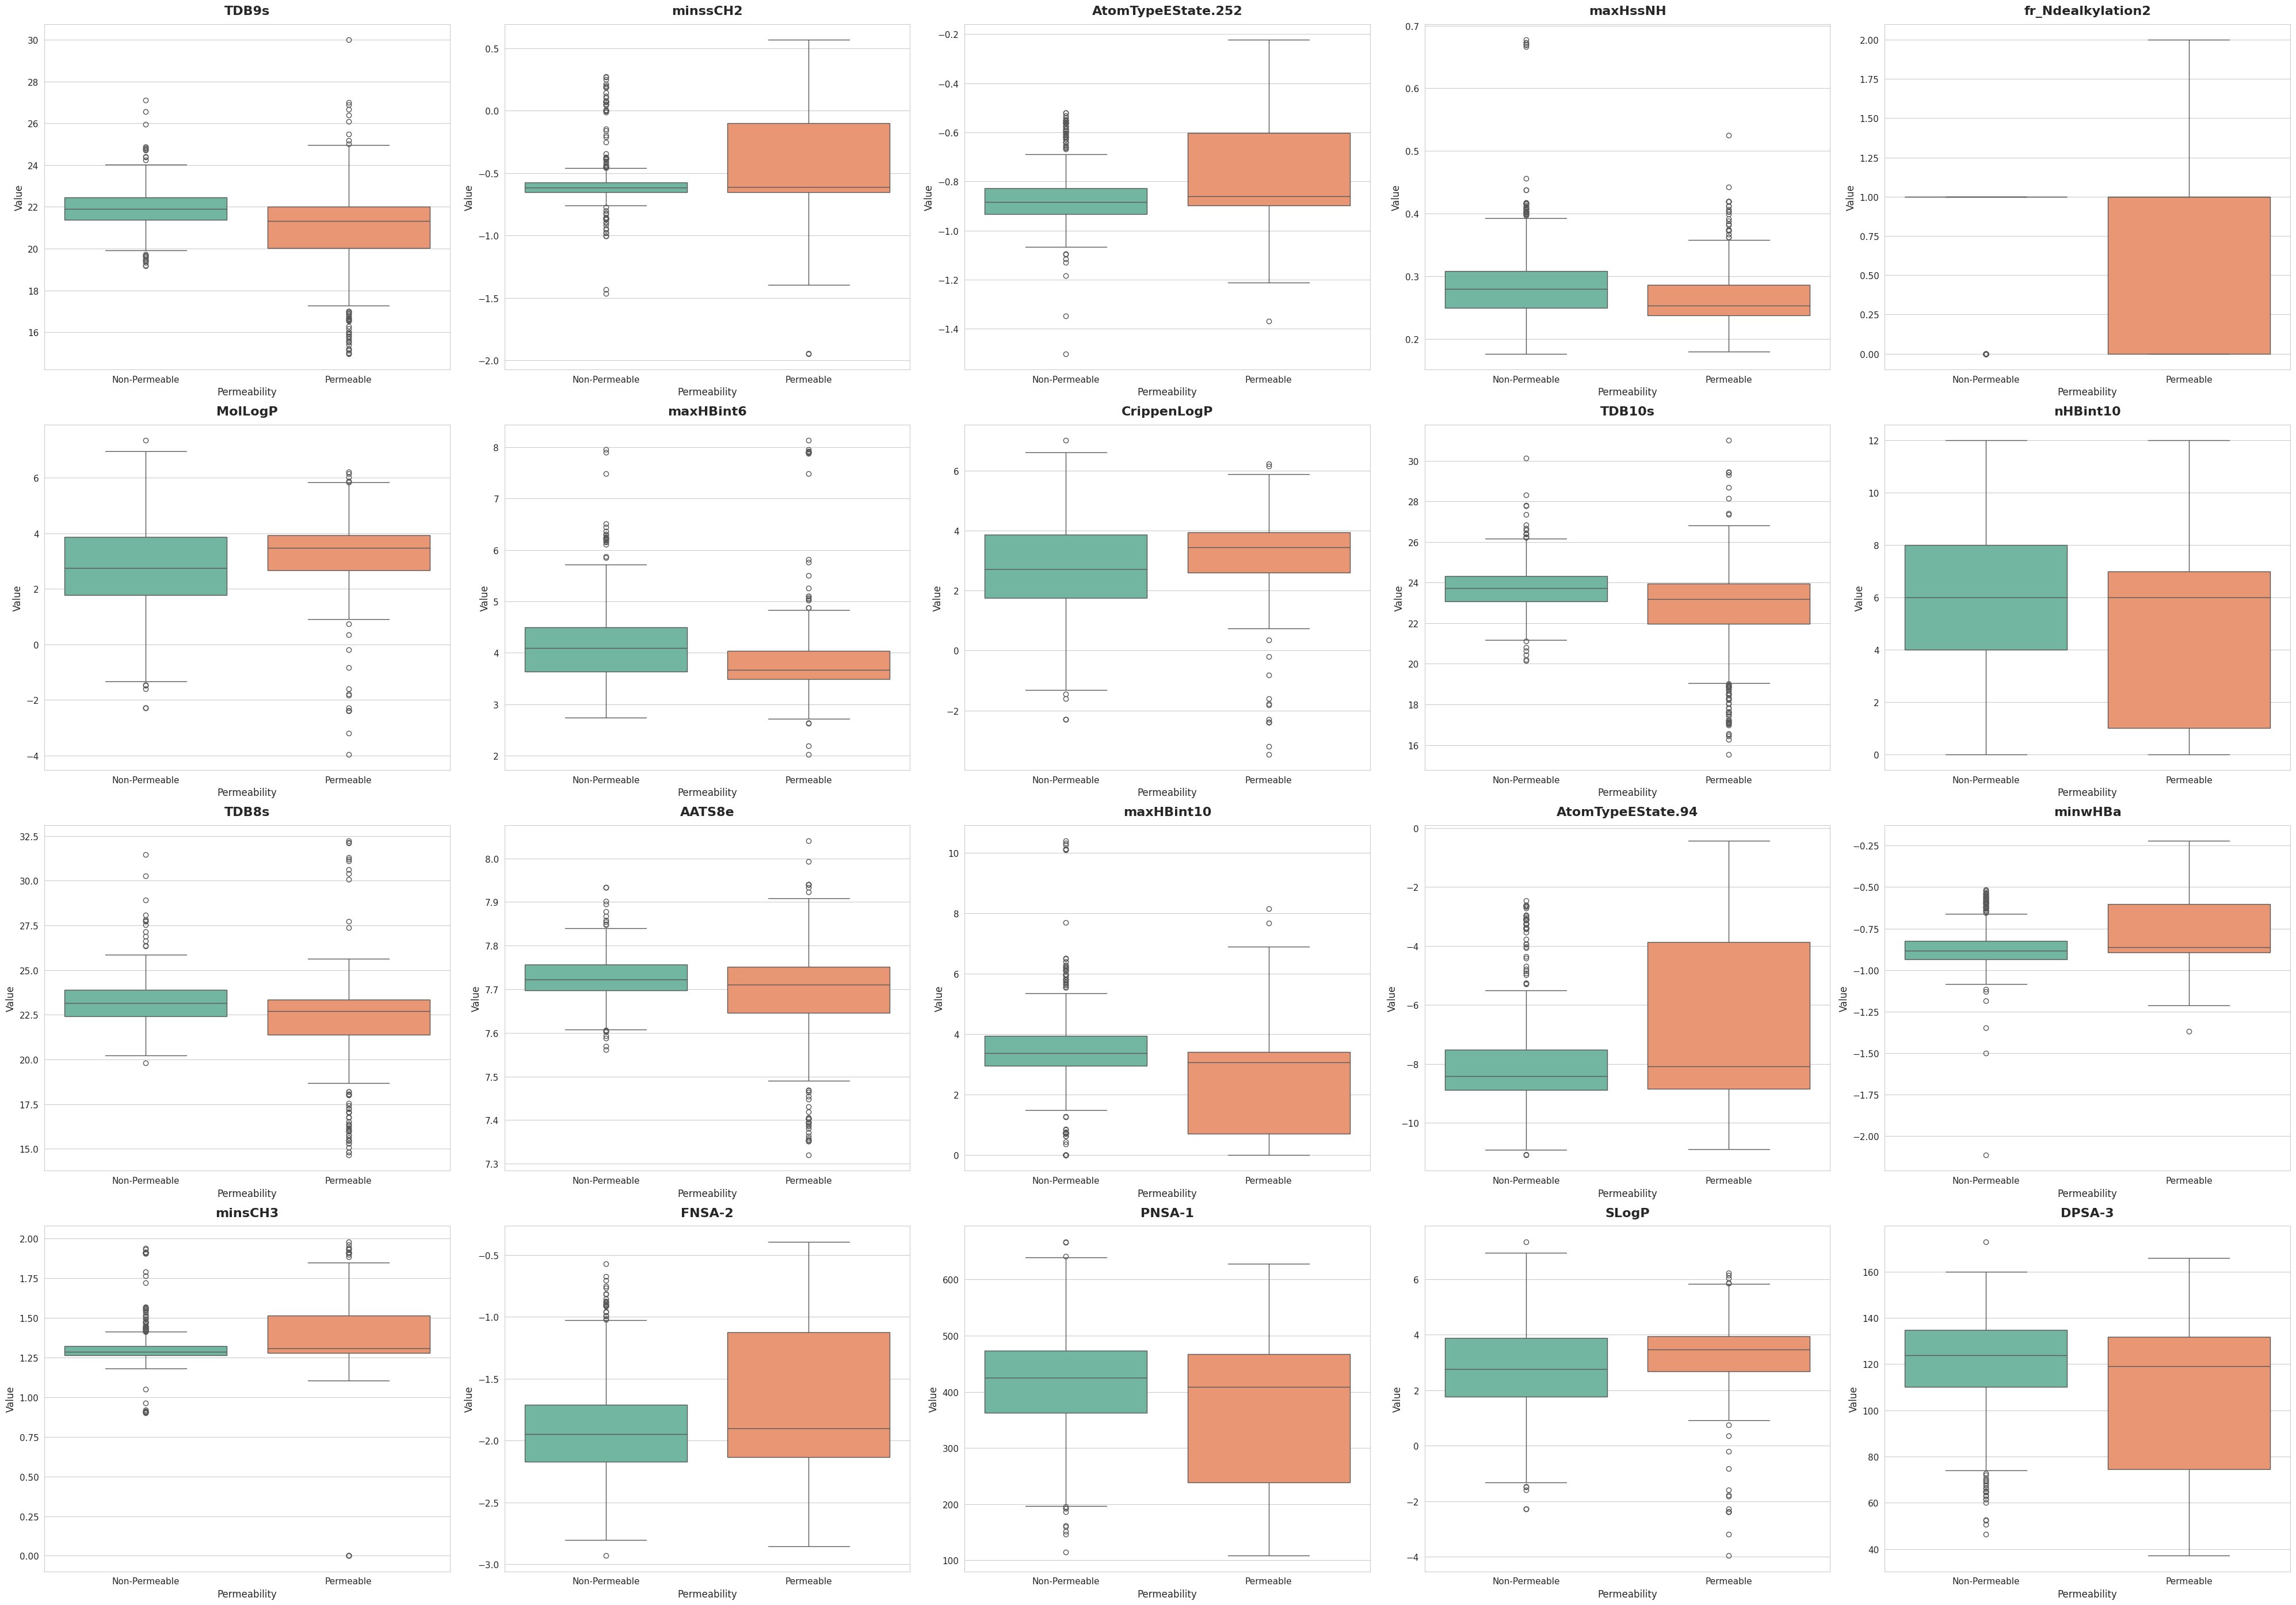

In [15]:
boxplots_diff_labels(train_df_labeled, feature_cols_train, label_col='Label', save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/desc_train_box_plot_caco2.png')


Top Features Correlation with Permeability by Label:

           Feature  Corr_Label_0  Corr_Label_1
             TDB9s     -0.356417     -0.656467
          minssCH2      0.186373      0.688234
AtomTypeEState.252      0.269288      0.710891
          maxHssNH     -0.255916      0.232542
 fr_Ndealkylation2     -0.254423     -0.590758
           MolLogP      0.318076     -0.315393
         maxHBint6     -0.319093      0.006487
       CrippenLogP      0.299144     -0.335363
            TDB10s     -0.225148     -0.638747
          nHBint10     -0.206377     -0.611915
             TDB8s     -0.274904     -0.606374
            AATS8e     -0.183329     -0.666874
        maxHBint10     -0.253196     -0.602532
 AtomTypeEState.94      0.246896      0.696460
           minwHBa      0.223789      0.706501
           minsCH3      0.268766      0.470642
            FNSA-2      0.187504      0.678382
            PNSA-1     -0.156776     -0.659377
             SLogP      0.318076     -0.315393
     

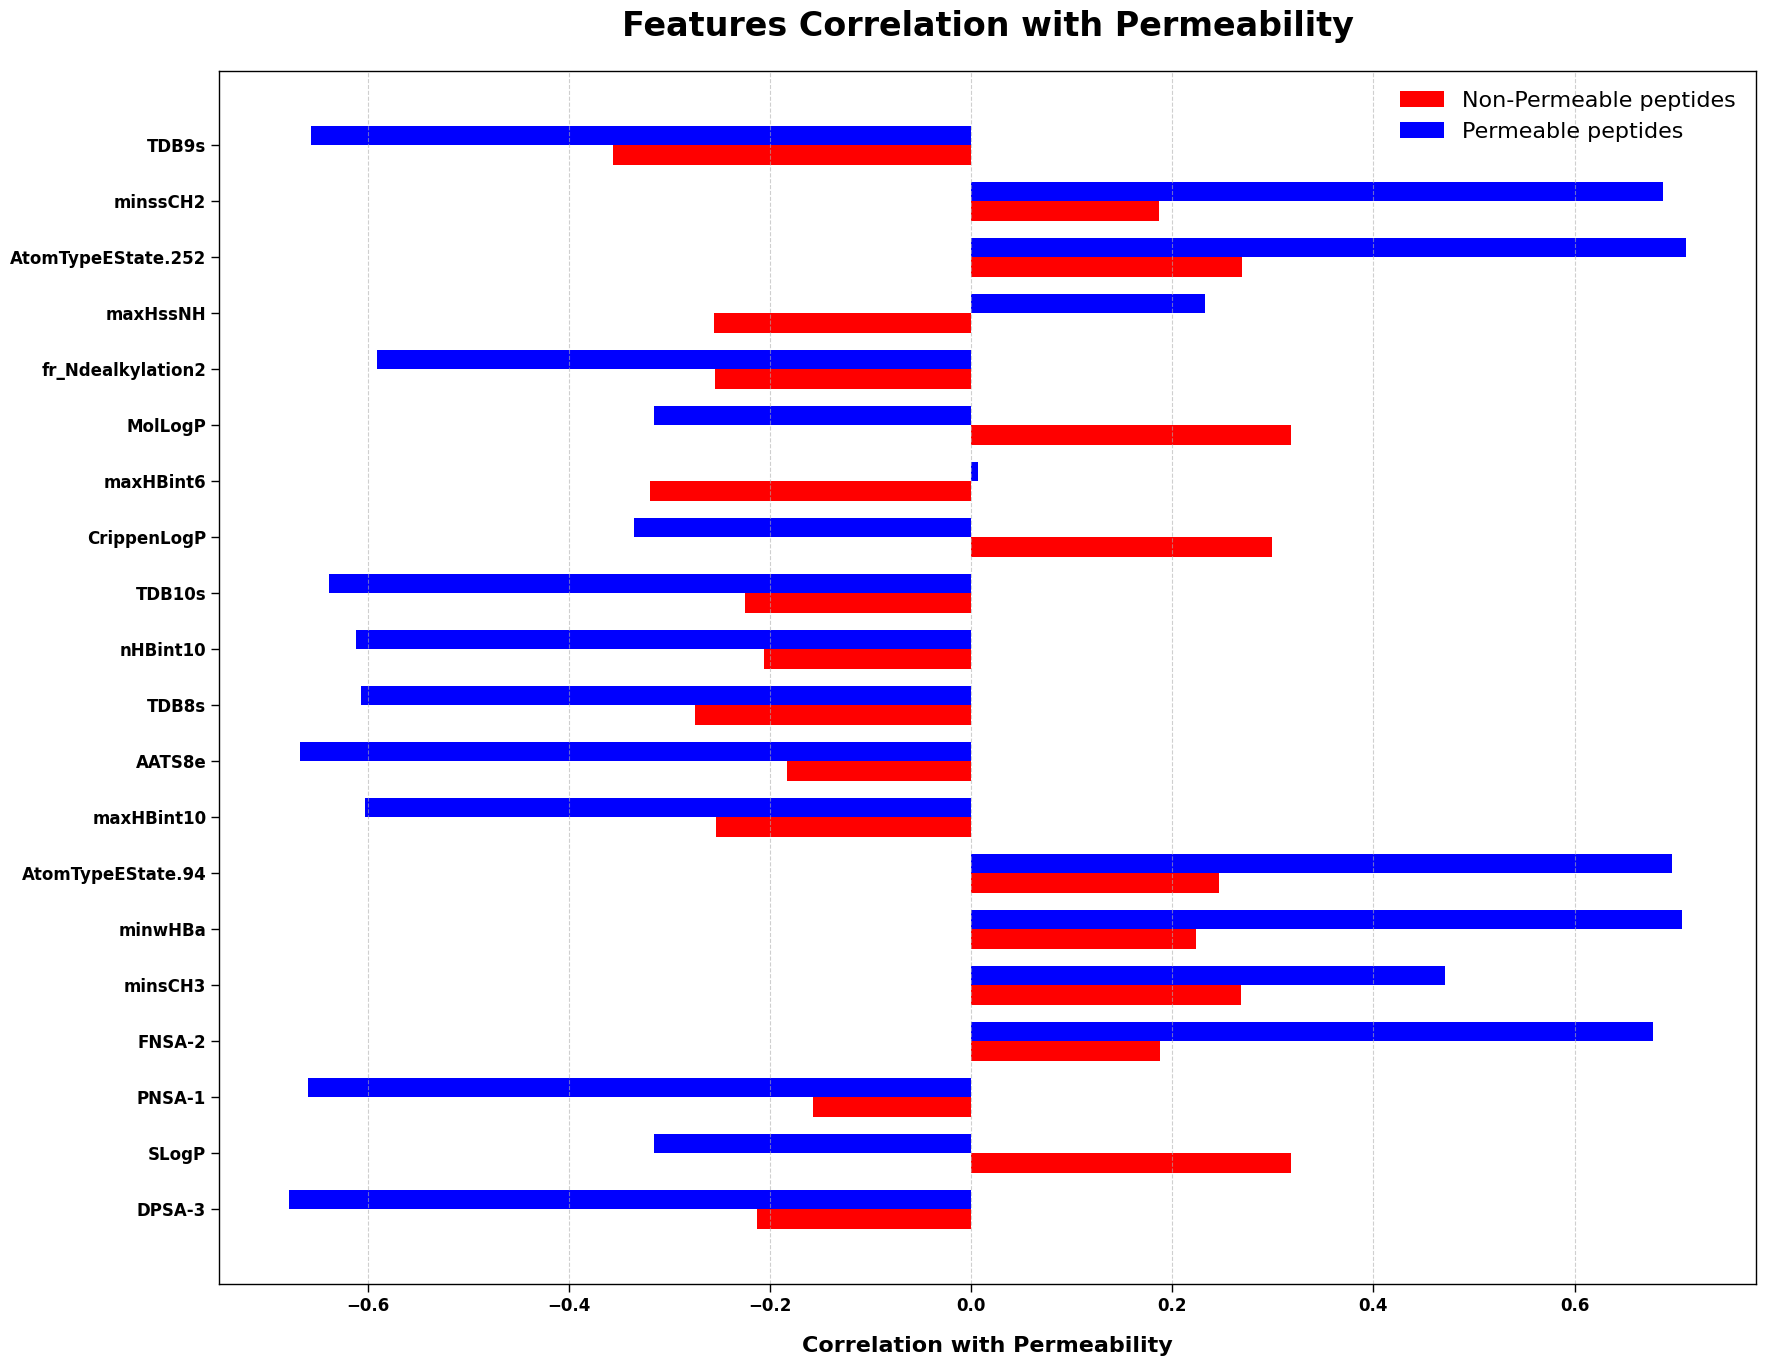

In [16]:
ET_top_features_list = ET_top_features_all['Feature'].to_list()
corr_df = plot_top_feature_correlations(
    train_df_labeled,
    label_col='Label',
    permeability_col='Permeability',
    top_desc_features=ET_top_features_list,
    save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/desc_train_corr_plot_caco2.png'
    
)

In [17]:
feature_cols_train

['TDB9s',
 'minssCH2',
 'AtomTypeEState.252',
 'maxHssNH',
 'fr_Ndealkylation2',
 'MolLogP',
 'maxHBint6',
 'CrippenLogP',
 'TDB10s',
 'nHBint10',
 'TDB8s',
 'AATS8e',
 'maxHBint10',
 'AtomTypeEState.94',
 'minwHBa',
 'minsCH3',
 'FNSA-2',
 'PNSA-1',
 'SLogP',
 'DPSA-3']

In [18]:
ttest_df_train = ttest_feature_tests(train_df_labeled, label_col='Label', feature_cols=feature_cols_train, save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/caco2_train_ttest.csv')
print(ttest_df_train)

Feature: TDB9s
T-Statistic: 10.0529, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: minssCH2
T-Statistic: -8.4550, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: AtomTypeEState.252
T-Statistic: -10.2512, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: maxHssNH
T-Statistic: 6.3804, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: fr_Ndealkylation2
T-Statistic: 7.4882, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: MolLogP
T-Statistic: -5.1626, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: maxHBint6
T-Statistic: 6.7496, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.


In [19]:
feature_cols_test = [col for col in test_df_labeled.columns if col not in ['ID', 'SMILES', 'Permeability', 'Label']]

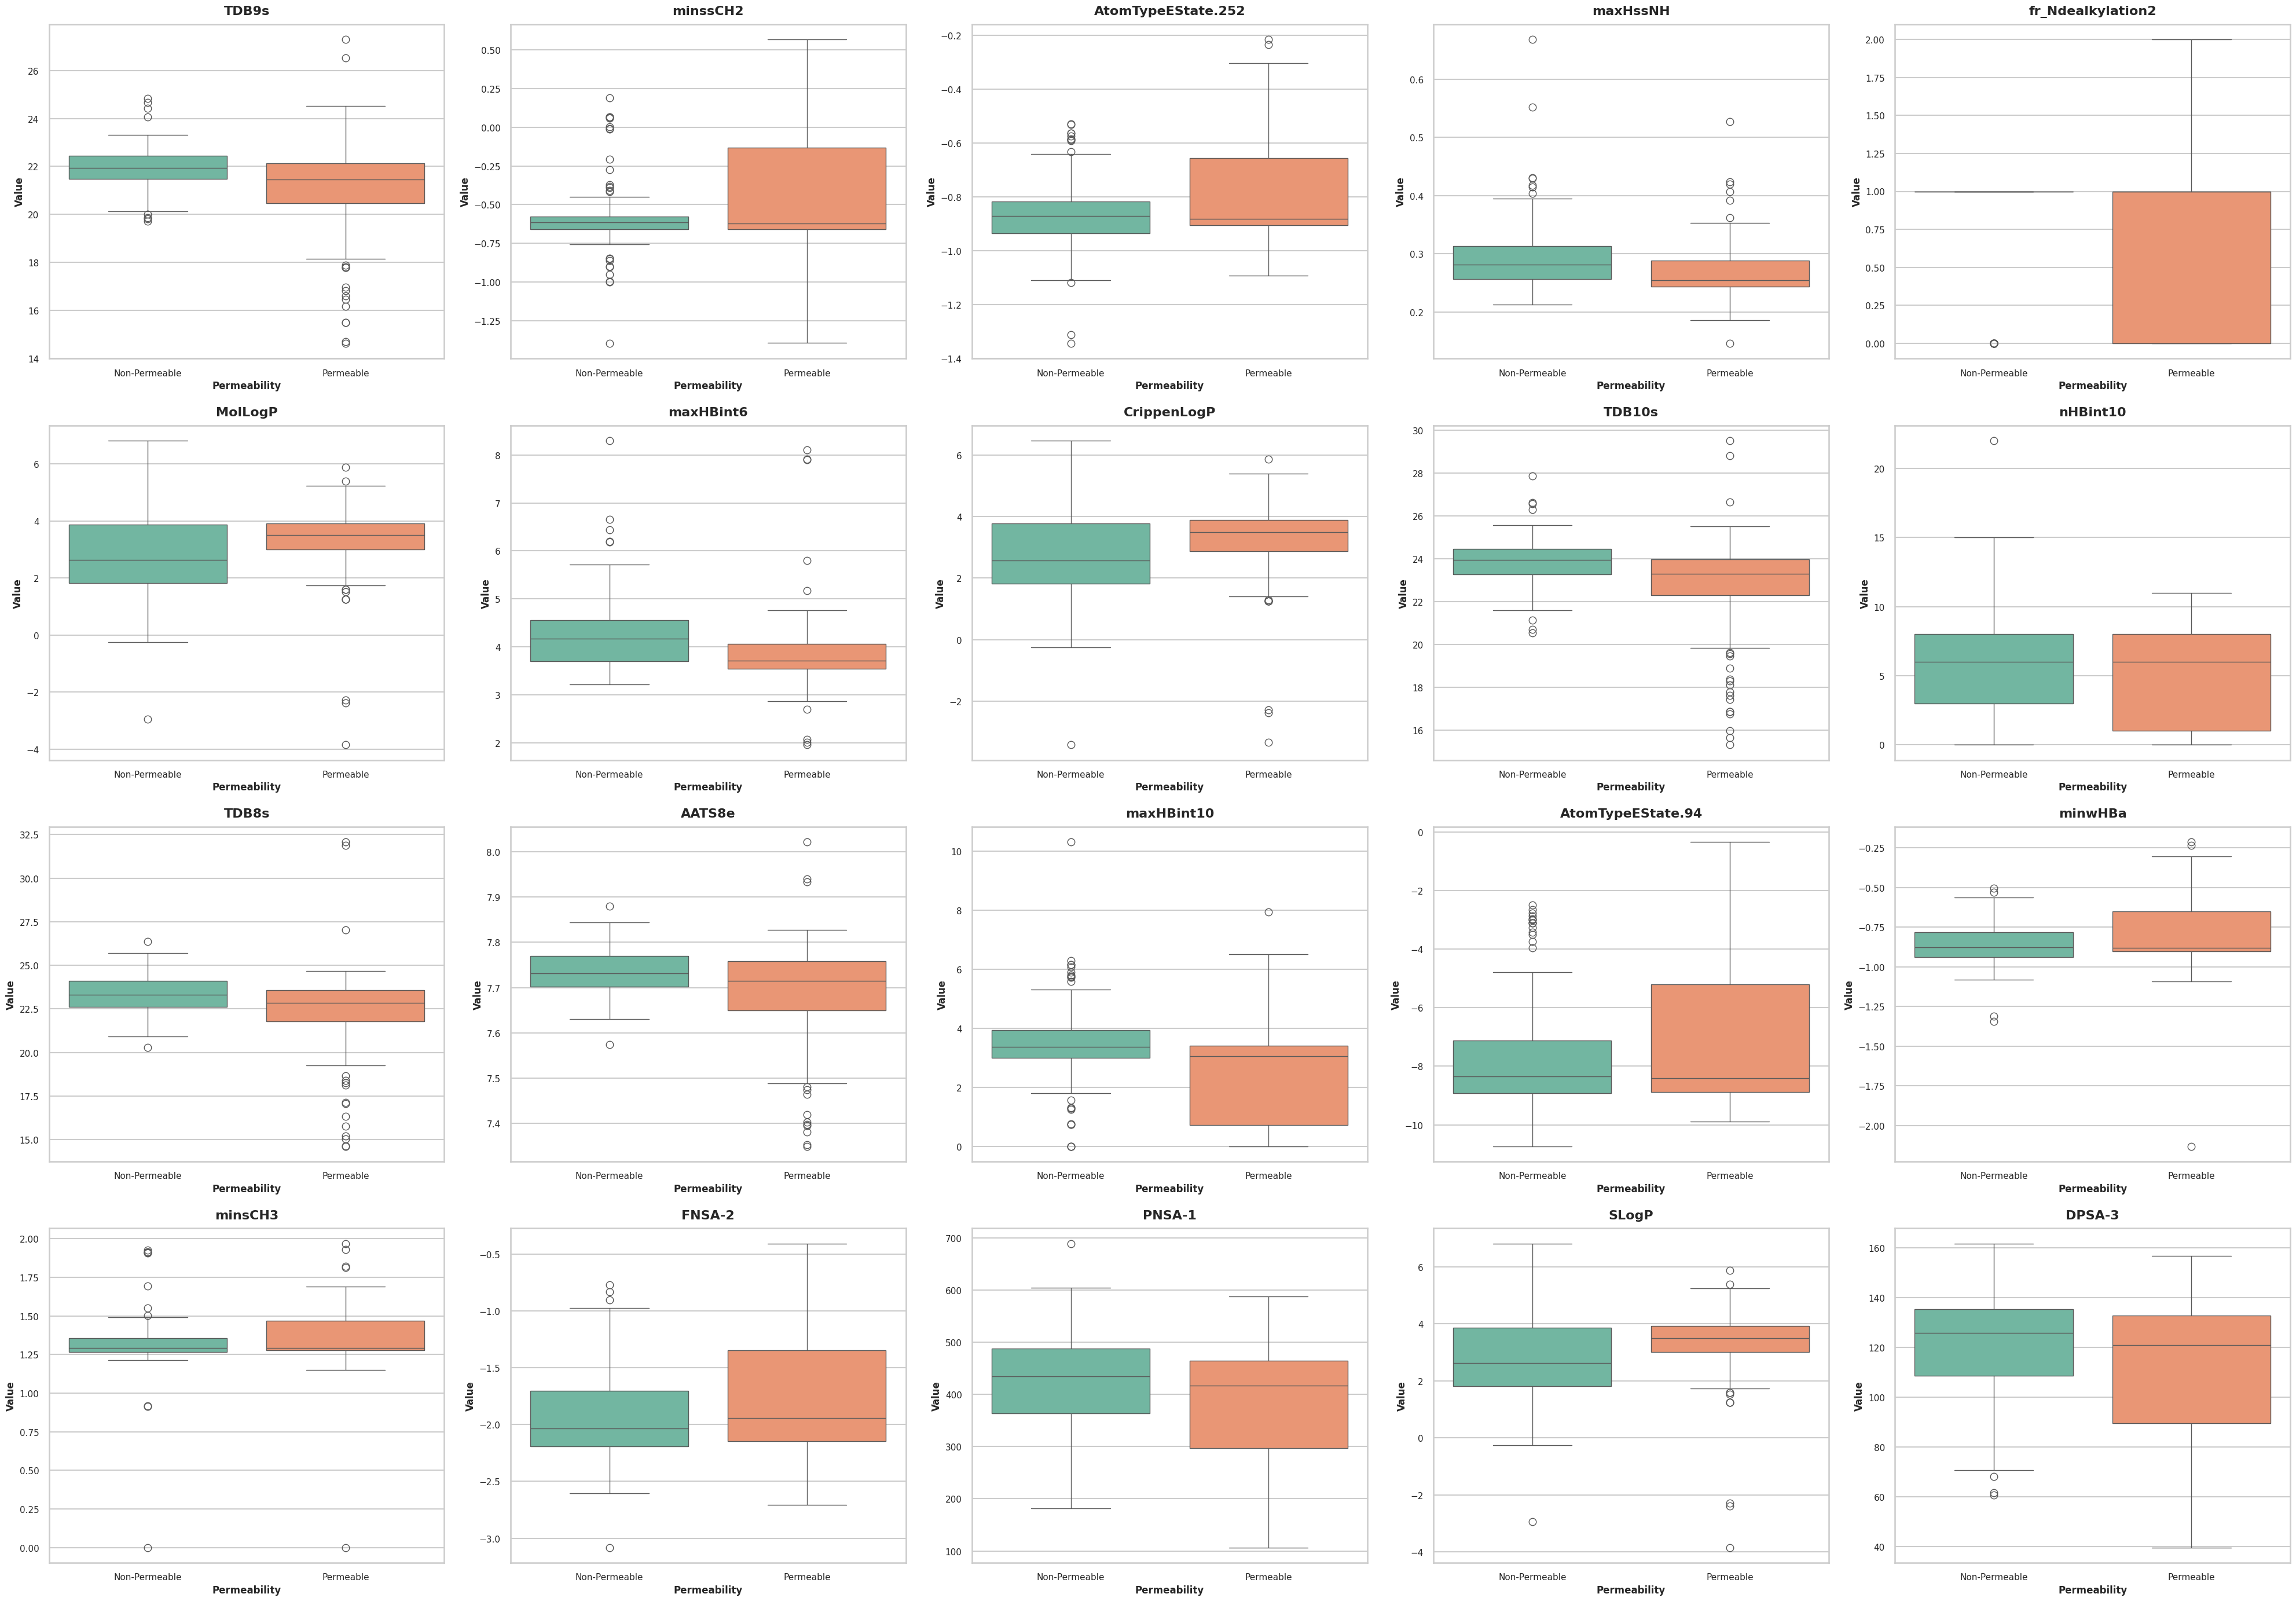

In [20]:
boxplots_diff_labels(test_df_labeled, feature_cols_test, label_col='Label', save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/desc_test_box_plot_caco2.png')


Top Features Correlation with Permeability by Label:

           Feature  Corr_Label_0  Corr_Label_1
             TDB9s     -0.162268     -0.633963
          minssCH2      0.122104      0.640488
AtomTypeEState.252      0.187860      0.709807
          maxHssNH     -0.227409      0.120281
 fr_Ndealkylation2     -0.311661     -0.597573
           MolLogP      0.248054     -0.331438
         maxHBint6     -0.247740     -0.136313
       CrippenLogP      0.235901     -0.356474
            TDB10s     -0.144576     -0.636623
          nHBint10     -0.038358     -0.603908
             TDB8s     -0.196238     -0.585147
            AATS8e     -0.035912     -0.655960
        maxHBint10     -0.125130     -0.576379
 AtomTypeEState.94      0.259607      0.699991
           minwHBa      0.184226      0.631307
           minsCH3      0.090489      0.519938
            FNSA-2      0.149682      0.671178
            PNSA-1     -0.130668     -0.653536
             SLogP      0.248054     -0.331438
     

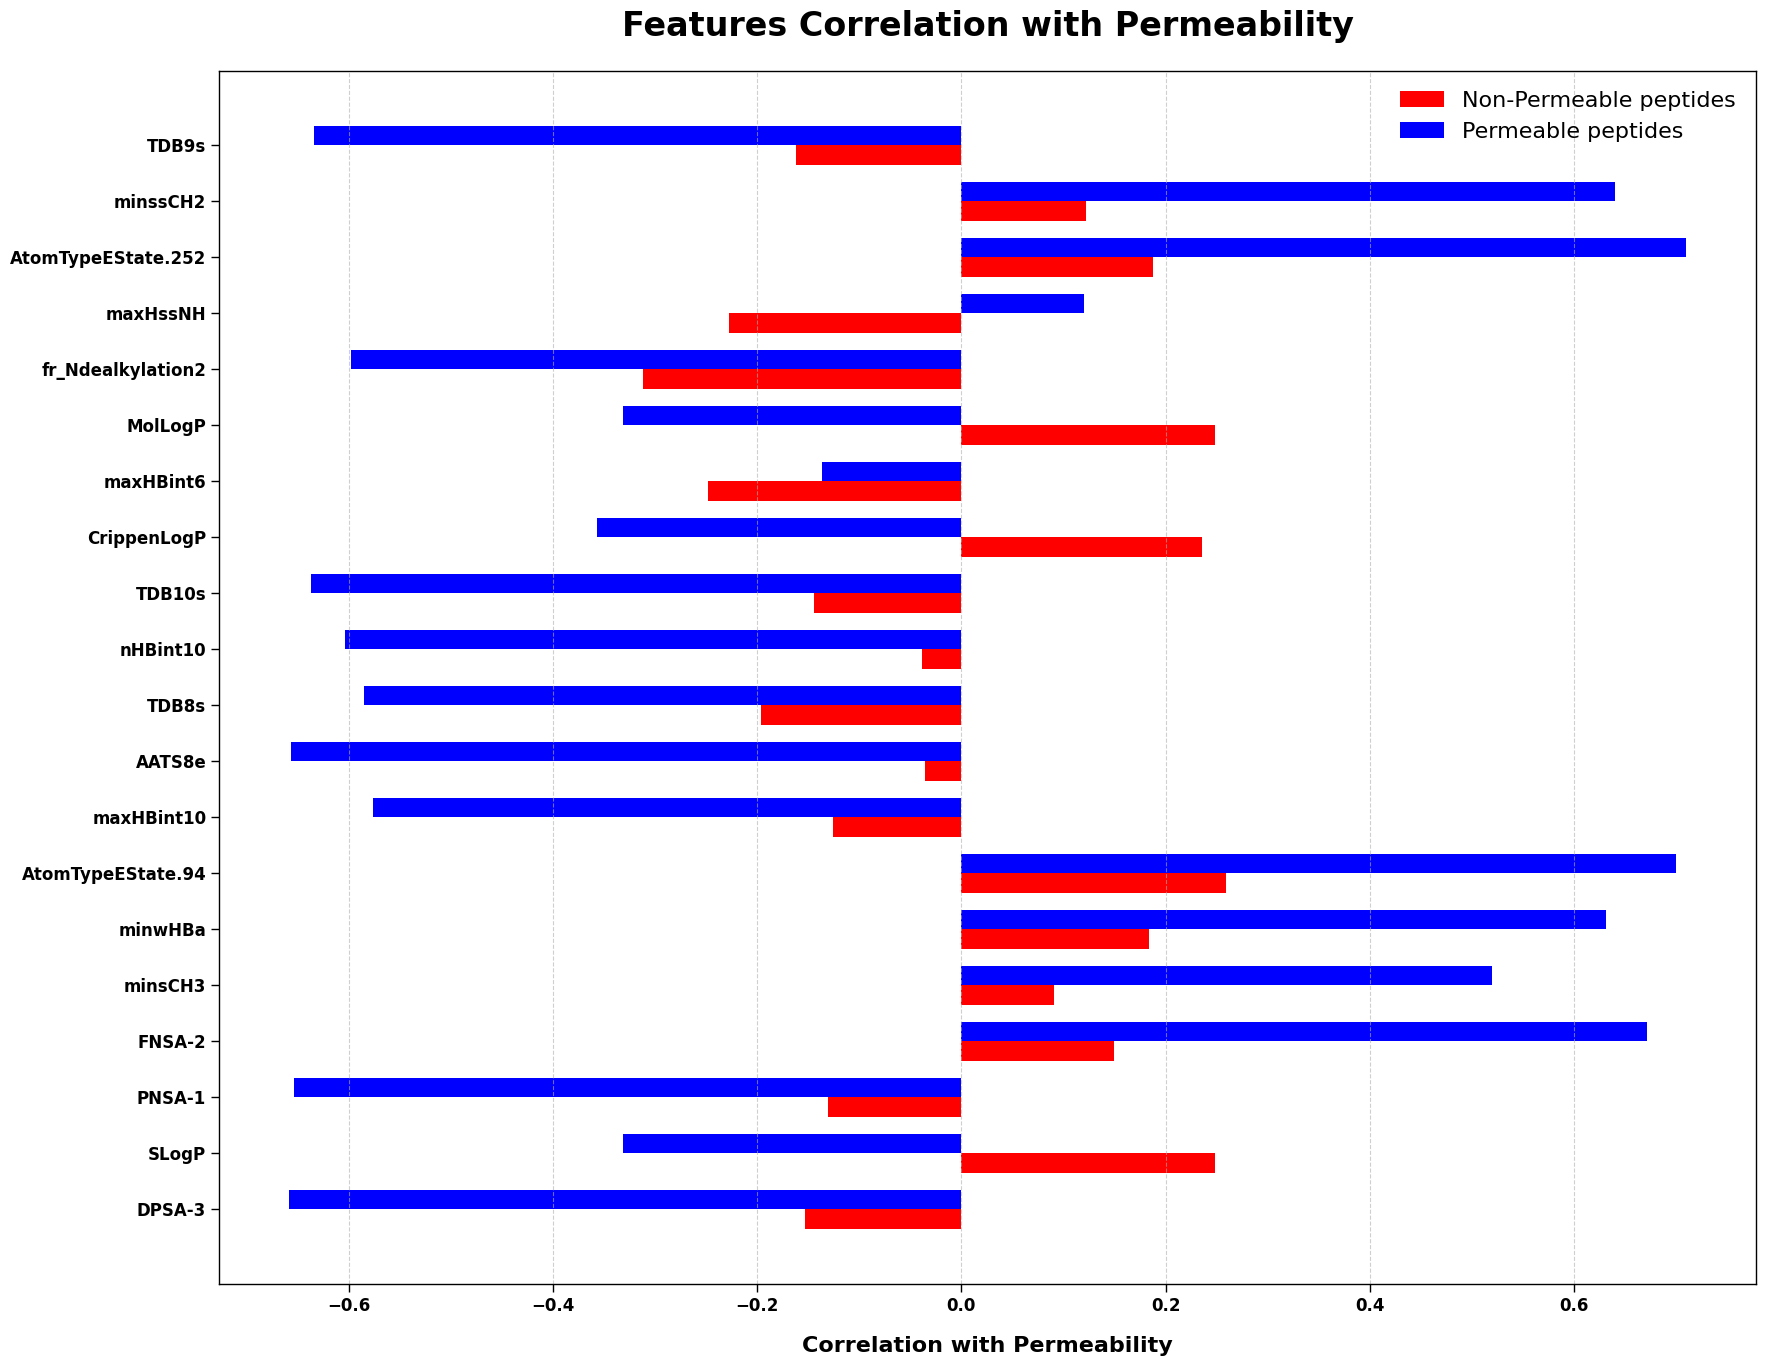

In [21]:
ET_top_features_list = ET_top_features_all['Feature'].to_list()

corr_df = plot_top_feature_correlations(
    test_df_labeled,
    label_col='Label',
    permeability_col='Permeability',
    top_desc_features=ET_top_features_list,
    save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/desc_test_corr_plot_caco2.png'
)

In [22]:
ttest_df_test = ttest_feature_tests(test_df_labeled, label_col='Label', feature_cols=feature_cols_test, save_path = '/home/users/akshay/PCPpred/Caco2/results/feature_analysis/caco2_ttest_test.csv')
print(ttest_df_test)

Feature: TDB9s
T-Statistic: 4.6276, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: minssCH2
T-Statistic: -3.6794, P-Value: 0.0003
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: AtomTypeEState.252
T-Statistic: -4.1726, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: maxHssNH
T-Statistic: 3.5396, P-Value: 0.0005
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: fr_Ndealkylation2
T-Statistic: 2.4459, P-Value: 0.0152
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: MolLogP
T-Statistic: -2.5562, P-Value: 0.0112
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: maxHBint6
T-Statistic: 4.0262, P-Value: 0.0001
Result: Reject the null hypothesis - significant difference between the two groups.

F